# StrainPhlAn multi-strain analysis: westernized (W) vs non-westernized (NW)

*Contents:*

1. Setup
2. Select SGBs present in both lifestyles
3. Load StrainPhlAn results
4. Sample-level multi-strain fraction
5. Sample × SGB table
6. Choosing the coverage threshold
7. Multi-strain rate by lifestyle (SGB level)
8. Polyallelic positions per SGB
9. Open questions

## 1. Setup

In [1]:
import os
print("Working directory:", os.getcwd())
print("Conda environment:", os.environ.get('CONDA_DEFAULT_ENV'))

Working directory: /shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/wnw/analysis
Conda environment: wnw


In [8]:
import pandas as pd
import numpy as np
from tqdm import tqdm

import matplotlib as mpl
mpl.rcParams["svg.fonttype"] = "none"

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu

# one global plotting style (the plot functions below set the same theme themselves)
sns.set_theme(style="whitegrid", font="sans-serif")

In [9]:
meta = pd.read_table("../data/nw_metadata.tsv")
meta = meta[meta['age'] != pd.NA]
meta = meta[meta['age'] != np.nan]
meta = meta[meta['age'].notna()]
meta = meta[meta['age'] != '1.083.333.333']
meta['age'] = meta['age'].astype(float)
meta = meta[meta['age'] > 16]
meta = meta[meta['study_name'] != 'HanniganGD_2017']
meta = meta.dropna(subset="age")

studies = meta.study_name.unique().tolist()

In [10]:
meta.head()

,study_name,sample_id,subject_id,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,...,non_westernized,sequencing_platform,PMID,number_reads,number_bases,minimum_read_length,median_read_length,NCBI_accession,curator,DNA_extraction_kit
0,NielsenHB_2014,O2_UC49_0,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,60584637.0,4.099972e+09,30.0,70.0,ERR210493;ERR210492;ERR209641;ERR209640,Paolo_Manghi,NaN
1,NielsenHB_2014,O2_UC49_2,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,56508214.0,3.775477e+09,30.0,70.0,ERR210495;ERR210494;ERR209643;ERR209642,Paolo_Manghi,NaN
2,NielsenHB_2014,O2_UC50_0,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,65105855.0,4.392995e+09,30.0,71.0,ERR210497;ERR210496;ERR209645;ERR209644,Paolo_Manghi,NaN
3,NielsenHB_2014,O2_UC50_2,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,53260679.0,3.596382e+09,30.0,70.0,ERR210500;ERR209648,Paolo_Manghi,NaN
4,NielsenHB_2014,O2_UC51_0,O2_UC51,stool,NaN,control,healthy,32.0,adult,female,...,no,IlluminaHiSeq,24997787.0,57486896.0,3.923766e+09,30.0,72.0,ERR210502;ERR210501;ERR209650;ERR209649,Paolo_Manghi,NaN


In [11]:
datadir = "/shares/CIBIO-Storage/CM/scratch/data/meta/"
spa_version = "strainphlan-4.1.0_vJan21_CHOCOPhlAnSGB_202103-multi-strain"

## 2. Select SGBs present in both lifestyles
Defines `sgbs_selected` (SGBs found in >10% of adult samples in **both** W and NW). It is defined once, here, because the loading loop in section 3 filters on it; the polyallelic analysis in section 8 reuses the same list.

In [12]:
# SGBs present in >10% of (adult) samples in BOTH lifestyles.
# Light first pass: only the SGB column of every results file is read.
sgb_hits = []
for study in tqdm(studies):
    study_dir = os.path.join(datadir, study, spa_version)
    if not os.path.exists(study_dir):
        continue
    for exsample in os.listdir(study_dir):
        filedir = os.path.join(study_dir, exsample, exsample, f"{exsample}.results.tsv")
        if os.path.exists(filedir):
            sgb_ids = pd.read_table(filedir, usecols=[0]).iloc[:, 0]
            if len(sgb_ids) > 0:
                sgb_hits.append(
                    pd.DataFrame({"study_name": study, "sample_id": exsample, "SGB": sgb_ids})
                )

sgb_hits = pd.concat(sgb_hits, ignore_index=True)

# keep samples that are in the (adult) metadata and attach their lifestyle
sgb_hits = sgb_hits.merge(
    meta[["study_name", "sample_id", "non_westernized"]], on=["study_name", "sample_id"]
)

sgb_counts = (
    sgb_hits.groupby("non_westernized")["SGB"]
    .value_counts()
    .reset_index(name="count")
)
sgb_counts["total_samples"] = sgb_counts.non_westernized.map(
    dict(meta.non_westernized.value_counts())
)
sgb_counts_enough = sgb_counts[
    (sgb_counts["count"] / sgb_counts["total_samples"]) > 0.10
]
sgbs_selected = list(
    sgb_counts_enough.SGB.value_counts()[
        sgb_counts_enough.SGB.value_counts() == 2
    ].index
)
print(f"Selected {len(sgbs_selected)} overlapping SGBs")

100%|███████████████████████████████████████████| 58/58 [01:21<00:00,  1.40s/it]


Selected 318 overlapping SGBs


## 3. Load StrainPhlAn results
Reads every `*.results.tsv` and builds
- `results`: one tuple per sample (counts of multi-/single-strain SGBs) → `res_df_meta`
- `full_results`: one DataFrame per sample → `full_results_df` in section 5

Only SGBs in `sgbs_selected` (section 2) are kept, so **sections 3 to 7 cover those SGBs only**.

`perc_multistrain` = `n_multistrain / n_total`, where `n_total` is the value stored by the loop.

In [13]:
results = []
full_results = []
for study in tqdm(studies):
    study_dir = os.path.join(datadir, study, spa_version)
    if os.path.exists(study_dir):
        samples = os.listdir(study_dir)
        for exsample in samples:
            filedir = os.path.join(study_dir, exsample, exsample, f"{exsample}.results.tsv")
            if os.path.exists(filedir):
                # multi-strain results
                df = pd.read_table(filedir, index_col=[0])
                if df.shape[0] > 0:
                    df = df[df.index.isin(sgbs_selected)]
                    df["study_name"] = study
                    df["sample_id"] = exsample
                    full_results.append(df)
                    ms = df.multi_strain.value_counts()
                    
                    try:
                        n_multi = ms[True] # n SGBs with multiple strains detected
                    except KeyError:
                        n_multi = 0
                    try:
                        n_single = ms[False] # n SGBs without multiple strains detected
                    except KeyError:
                        n_single = 0

                    n_total = n_multi + n_single
                    results.append((study, exsample, n_multi, n_single, n_total + 1))

100%|███████████████████████████████████████████| 58/58 [01:00<00:00,  1.05s/it]


In [14]:
colselect = [
    'sample_id', 
    'study_name', 
    'subject_id', 
    'age',
    'gender',
    'country', 
    'non_westernized',
    'sequencing_platform', 
    'number_reads', 
    'number_bases',
    'minimum_read_length',
    'median_read_length',
    'DNA_extraction_kit',
    "n_multistrain", 
    "n_singlestrain", 
    "n_total"
]

In [15]:
cols = ["study_name", "sample_id", "n_multistrain", "n_singlestrain", "n_total"]
res_df = pd.DataFrame(results, columns = cols)

res_df_meta = res_df.merge(meta, on=["sample_id","study_name"])
res_df_meta = res_df_meta[colselect]
res_df_meta["perc_multistrain"] = res_df_meta["n_multistrain"] / res_df_meta["n_total"]

## 4. Sample-level multi-strain fraction

In [16]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

df = res_df_meta.copy()

# 1. Select the relevant columns and drop rows with missing values
model_cols = ["perc_multistrain", "non_westernized", "age", "gender", "number_reads", "study_name"]
df_clean = df[model_cols].dropna().copy()

# 2. Fit the GLM using the cleaned dataframe
formula = """
perc_multistrain ~ C(non_westernized) 
                 + age 
                 + C(gender) 
                 + np.log1p(number_reads)
"""

model_clustered = smf.glm(
    formula=formula, 
    data=df_clean, 
    family=sm.families.Binomial()
).fit(
    cov_type="cluster", 
    cov_kwds={"groups": df_clean["study_name"]}
)

print(model_clustered.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       perc_multistrain   No. Observations:                 5645
Model:                            GLM   Df Residuals:                     5640
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1476.1
Date:                Tue, 22 Sep 2026   Deviance:                       242.69
Time:                        10:42:18   Pearson chi2:                     284.
No. Iterations:                     5   Pseudo R-squ. (CS):           0.007826
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

<AxesSubplot:xlabel='non_westernized', ylabel='perc_multistrain'>

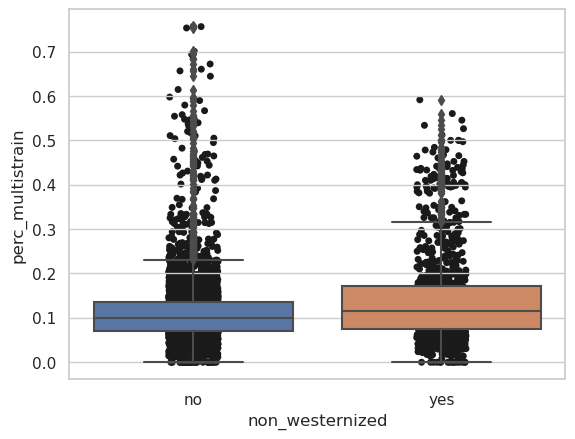

In [17]:
sns.boxplot(
    data = res_df_meta,
    x = "non_westernized",
    y = "perc_multistrain",
    zorder = 1,
)

sns.stripplot(
    data = res_df_meta,
    x = "non_westernized",
    y = "perc_multistrain",
    color = "k",
    zorder = 0
)

## 5. Sample × SGB table
`full_results_df` is rebuilt from scratch here, so keep these three cells together and in this order.

In [18]:
full_results_df = pd.concat(full_results)
full_results_df = full_results_df.reset_index().rename(columns={"index":"sgb_id"})
full_results_df.head()

/tmp/ipykernel_1281070/3697935510.py:1: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  full_results_df = pd.concat(full_results)


,sgb_id,n_markers_present,n_positions_total,coverage_25th,coverage_50th,coverage_75th,perc_positions_outlier_covered,n_markers_outlier_covered,n_positions_retained,n_markers_retained,...,r_fit_var,snp_rate_var_ut,r_fit_var_ut,fit_method,pred_recall,pred_precision,pred_precision_support,output_minor_strain,study_name,sample_id
0,t__SGB14253,42,6222,1.0,1.0,1.0,0.0,0,6222,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NielsenHB_2014,MH0001
1,t__SGB14311,132,26325,1.0,1.0,1.0,0.0,0,26325,132,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NielsenHB_2014,MH0001
2,t__SGB14546_group,128,24481,1.0,1.0,1.0,0.0,0,24481,128,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NielsenHB_2014,MH0001
3,t__SGB14861,131,26527,1.0,1.0,1.0,0.0,0,26527,131,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NielsenHB_2014,MH0001
4,t__SGB14991,53,6667,1.0,1.0,1.0,0.0,0,6667,53,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NielsenHB_2014,MH0001


In [19]:
sample2lifestyle = dict(zip(meta.sample_id, meta.non_westernized))

In [20]:
full_results_df["non_westernized"] = full_results_df.sample_id.map(sample2lifestyle)

## 6. Choosing the coverage threshold
Exploration only: nothing in section 7 depends on these cells except that `full_results_df` exists.

In [21]:
print(full_results_df.coverage_50th.min())
print(full_results_df.coverage_50th.max())
print(full_results_df.coverage_50th.mean())

1.0
6303.0
7.062057662190873


In [22]:
print(full_results_df.shape[0])

(full_results_df.coverage_50th > 10).sum()

1213863


129866

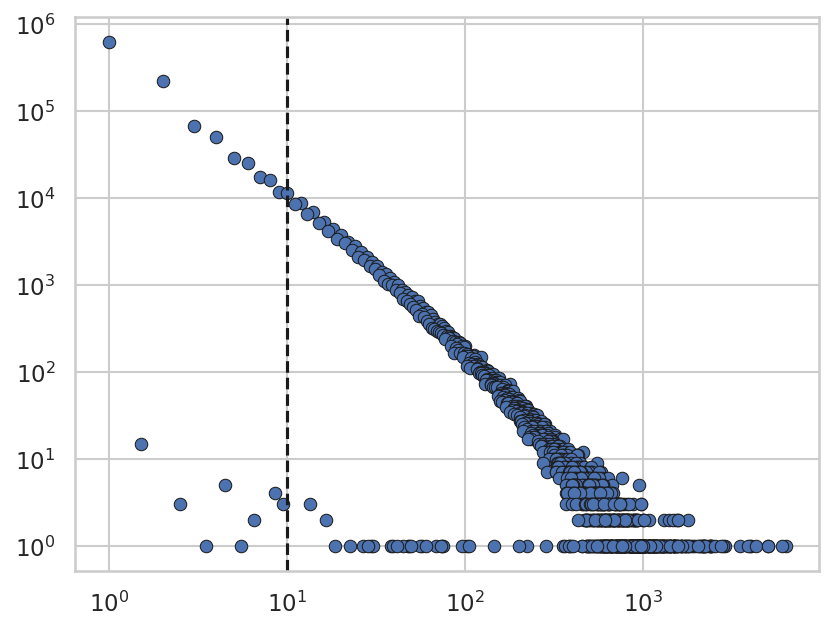

In [23]:
median_coverage = full_results_df.coverage_50th.value_counts()
x = list(median_coverage.index)
y = list(median_coverage.values)

fig, ax = plt.subplots(dpi=150)
sns.scatterplot(x=x, y=y, edgecolor="k")
plt.xscale("log", base=10)
ax.set_yscale("log", base=10)

ax.axvline(10, c="k", ls="--")

In [24]:
counts_thresh = 20
nsgbs_left = []
for thresh in range(1,51,1):
    
    df_counts = (
        full_results_df[full_results_df.coverage_50th >= thresh]
        .groupby("sgb_id")
        .non_westernized.value_counts()
        .reset_index(name="count")
    )
    
    valid_sgbs = df_counts.groupby("sgb_id").filter(
        lambda g: len(g) == 2 and (g["count"] > counts_thresh).all()
    )
    
    nsgbs_left.append((thresh, valid_sgbs.sgb_id.nunique()))

nsgbs_left = pd.DataFrame(nsgbs_left, columns=["coverage_threshold","n_sgbs_left"])

Text(0.5, 1.0, 'SGBs with >20 occurrences in both lifestyles')

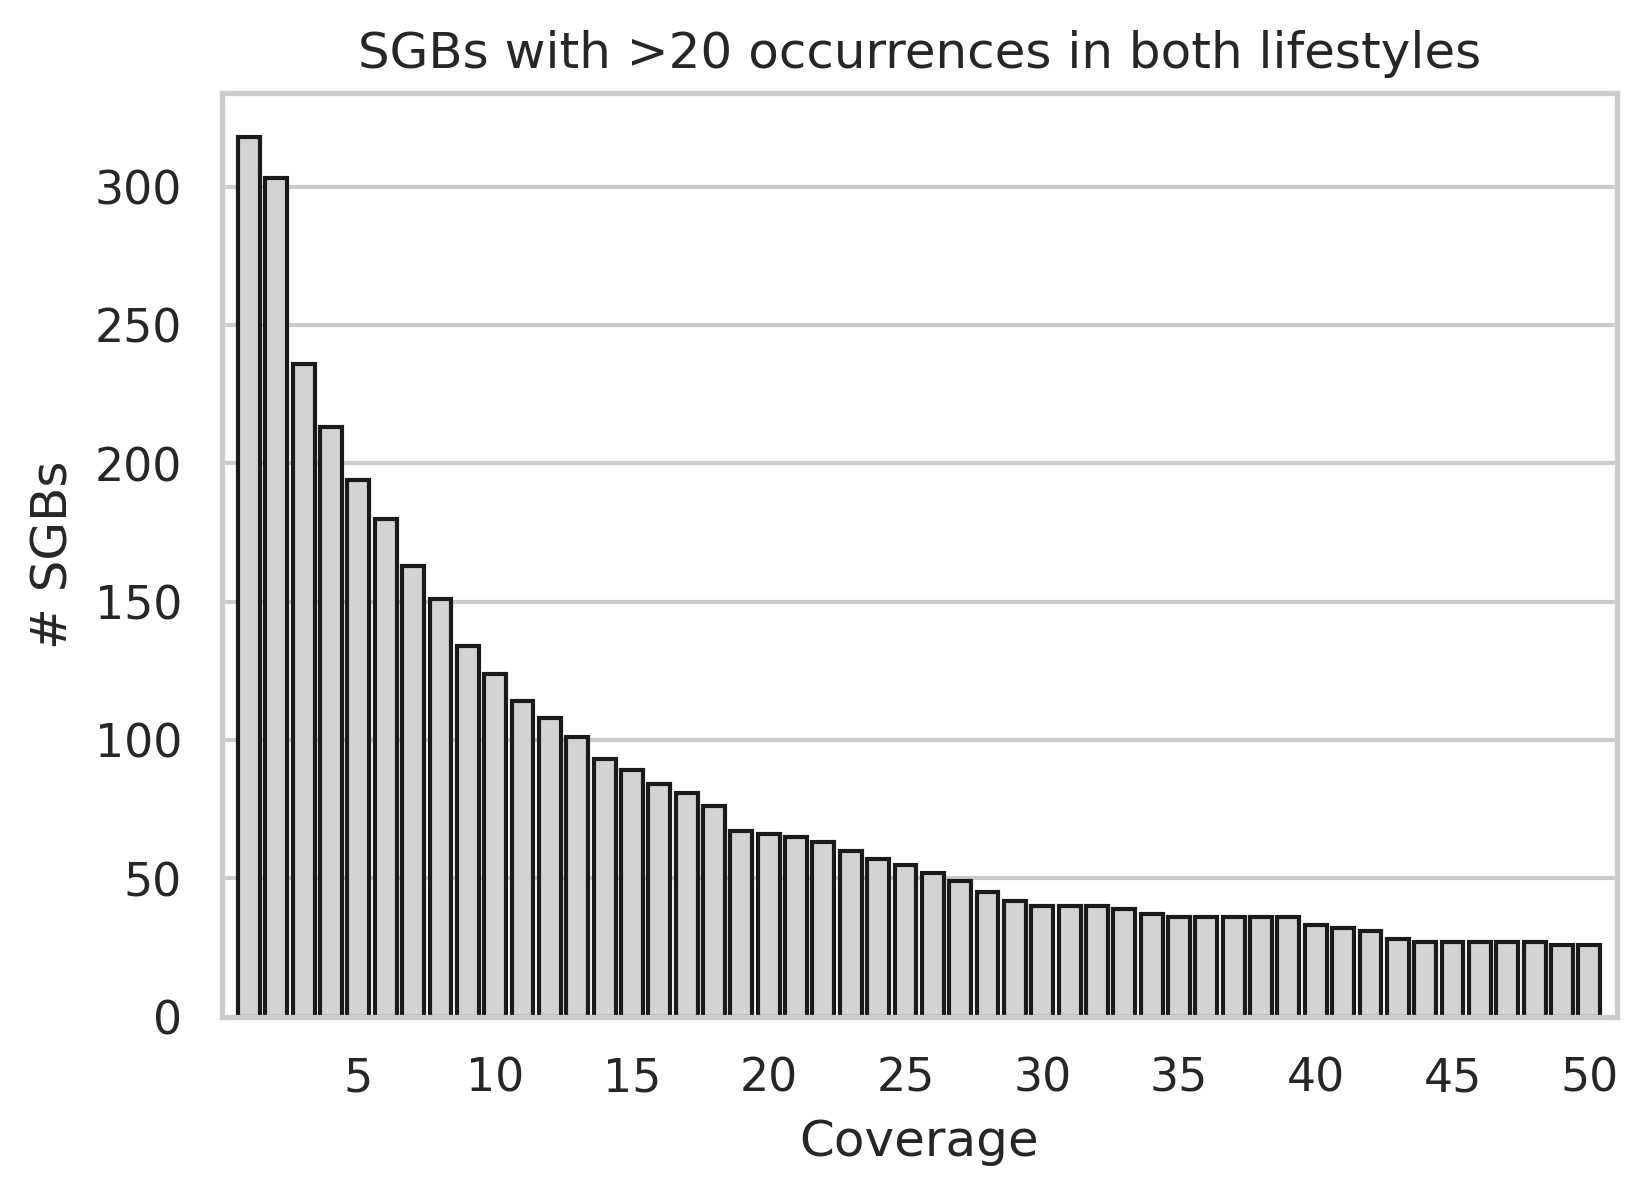

In [25]:
fig, ax = plt.subplots(figsize=(6,4), dpi=300)
sns.barplot(data=nsgbs_left, x="coverage_threshold", y="n_sgbs_left", color="lightgrey", edgecolor="k")
ax.set_xticks(range(4,50,5))
ax.set_xlim(-1, 50)

ax.set_xlabel("Coverage")
ax.set_ylabel("# SGBs")

ax.set_title("SGBs with >20 occurrences in both lifestyles")

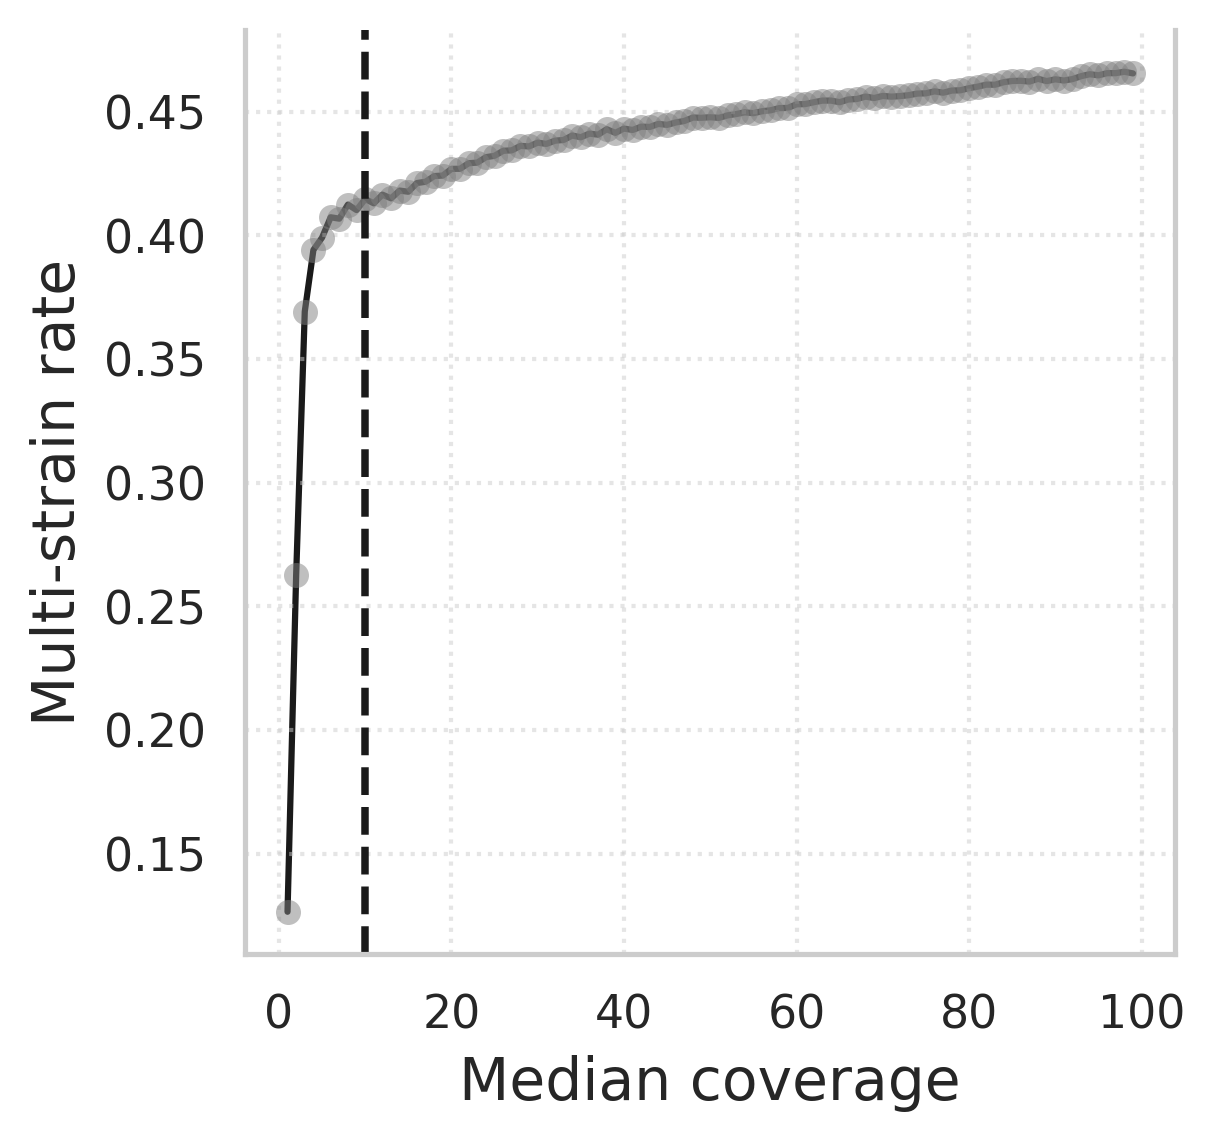

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Compute multi-strain rate and sample counts across coverage thresholds
coverage_cutoffs = range(1, 100, 1)  # 1x to 50x
saturation_data = []

for cov in coverage_cutoffs:
    # Subset to observations meeting or exceeding the coverage threshold
    sub = full_results_df[full_results_df["coverage_50th"] >= cov]

    rate = sub["multi_strain"].mean()
    std = sub["multi_strain"].std()
    n_obs = len(sub)

    saturation_data.append(
        {"coverage_cutoff": cov, "ms_mean": rate, "ms_std": std, "n_samples": n_obs}
    )

sat_df = pd.DataFrame(saturation_data)

# 2. Plot Saturation Curve
sns.set_theme(style="whitegrid", font="sans-serif")
fig, ax1 = plt.subplots(figsize=(4,4), dpi=300)

# Line plot for multi-strain rate
color_line = "#2b5c8f"
ax1.plot(
    sat_df["coverage_cutoff"],
    sat_df["ms_mean"],
    color="k",
    linewidth=1.5,
    zorder=0
)

ax1.scatter(
    sat_df["coverage_cutoff"],
    sat_df["ms_mean"],
    # color=color_line,
    linewidth=0,
    alpha=0.5,
    color="grey",
    edgecolor="lightgrey",
    zorder=1,
)

# Highlight selected 10x threshold with a dashed vertical line
ax1.axvline(
    x=10, color="k", linestyle="--", linewidth=1.8
)

# Aesthetics
ax1.set_xlabel("Median coverage", fontsize=14)
ax1.set_ylabel("Multi-strain rate", fontsize=14)
# ax1.tick_params(axis="y")
# ax1.set_xticks(range(0, 51, 10))
ax1.spines["top"].set_visible(False)
ax1.grid(True, linestyle=":", alpha=0.5)


# plt.tight_layout()
plt.savefig("../revision/coverage_saturation_curve.png", dpi=300, bbox_inches="tight")
plt.show()

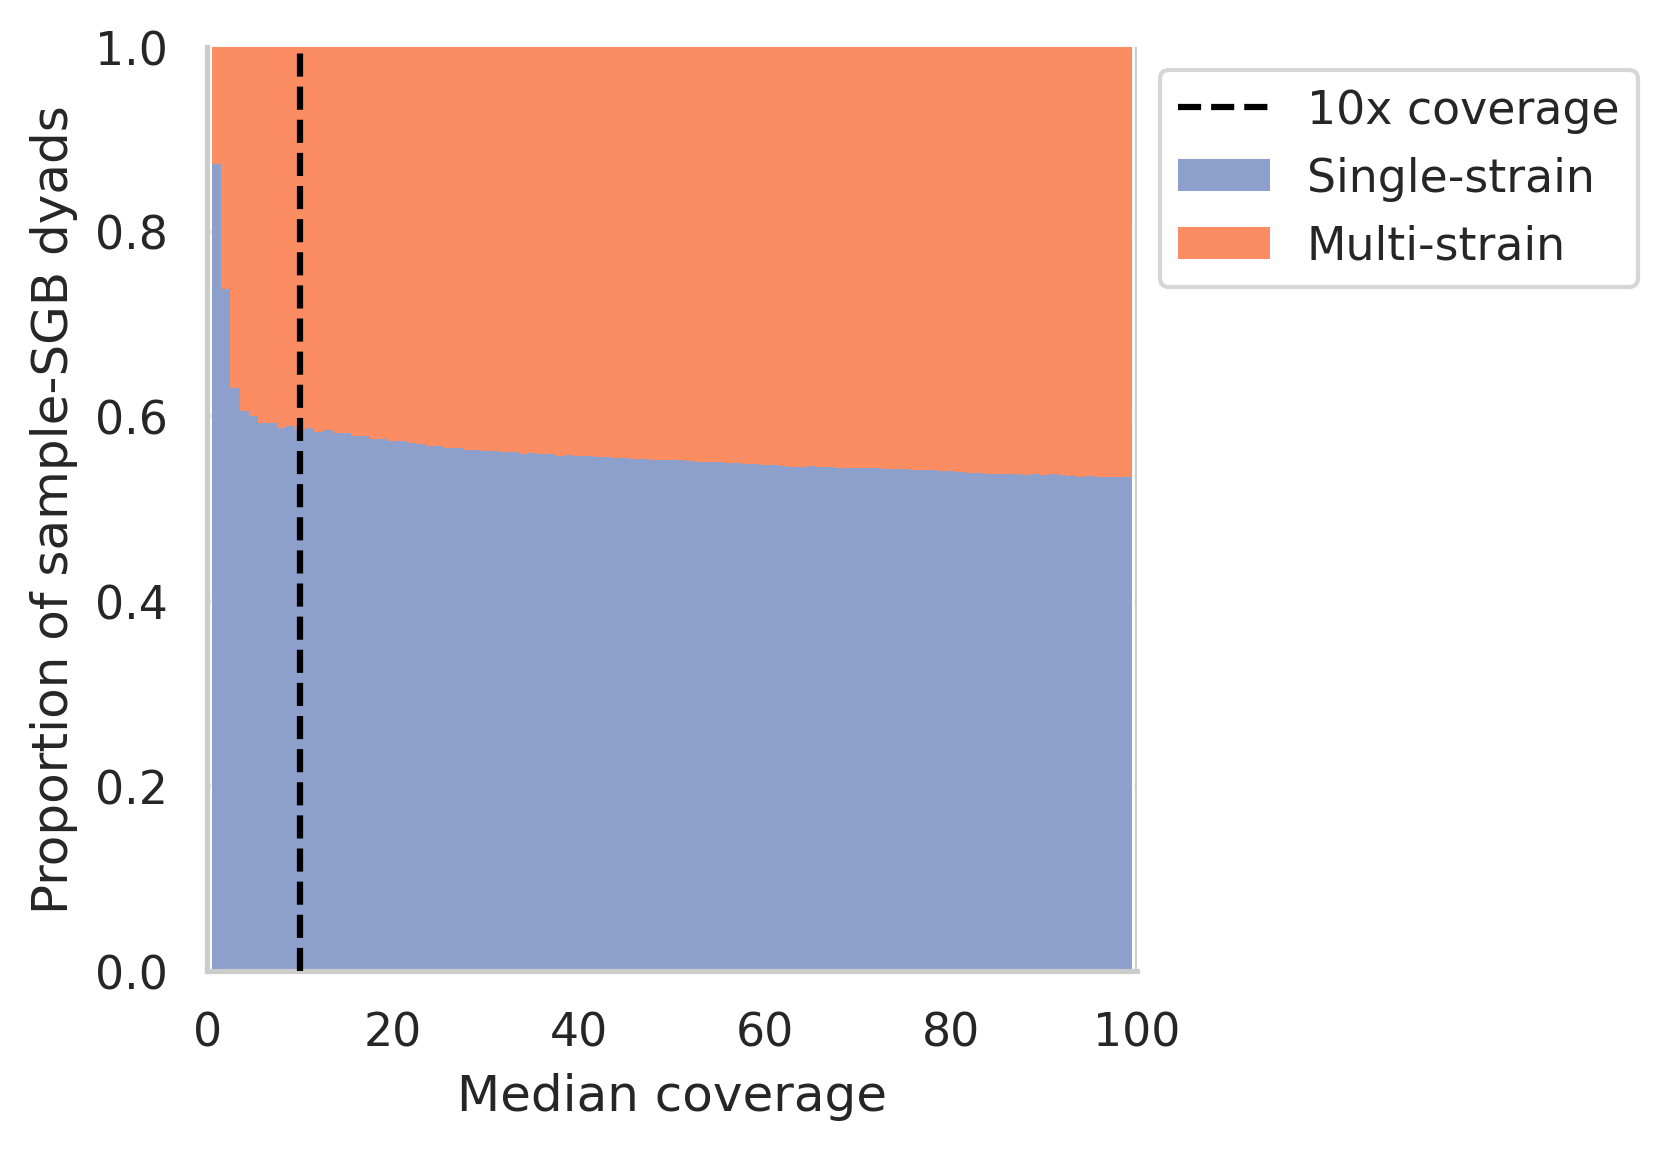

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Compute single-strain vs. multi-strain proportions across coverage cutoffs
coverage_cutoffs = range(1, 100, 1)
saturation_data = []

for cov in coverage_cutoffs:
    sub = full_results_df[full_results_df["coverage_50th"] >= cov]

    ms_rate = sub["multi_strain"].mean()
    single_rate = 1.0 - ms_rate
    n_obs = len(sub)

    saturation_data.append(
        {
            "coverage_cutoff": cov,
            "single_strain_rate": single_rate,
            "multi_strain_rate": ms_rate,
            "n_samples": n_obs,
        }
    )

sat_df = pd.DataFrame(saturation_data)

# 2. Plot Stacked Bar Chart
sns.set_theme(style="whitegrid", font="sans-serif")
fig, ax = plt.subplots(figsize=(4,4), dpi=300)

color_single = "#8da0cb"  # Light muted blue
color_multi = "#fc8d62"  # Muted orange/coral

# Bottom bar: Single strain
bar_single = ax.bar(
    sat_df["coverage_cutoff"],
    sat_df["single_strain_rate"],
    width=1.0,
    color=color_single,
    edgecolor="none",
    label="Single-strain",
)

# Top bar: Multi strain stacked on top
bar_multi = ax.bar(
    sat_df["coverage_cutoff"],
    sat_df["multi_strain_rate"],
    bottom=sat_df["single_strain_rate"],
    width=1.0,
    color=color_multi,
    edgecolor="none",
    label="Multi-strain",
)

# Highlight selected 10x threshold
ax.axvline(
    x=10,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="10x coverage",
    zorder=3,
)

# Aesthetics
ax.set_xlabel("Median coverage", fontsize=12)
ax.set_ylabel("Proportion of sample-SGB dyads", fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_xlim(0, 100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle=":", alpha=0.5, axis="y")

ax.legend(frameon=True, loc="upper left", bbox_to_anchor=(1, 1))

# plt.tight_layout()
plt.savefig(
    "../revision/coverage_saturation_stacked_bar.svg",
    # dpi=300,
    bbox_inches="tight",
)
plt.show()

## 7. Multi-strain rate by lifestyle (SGB level)
This is the format analysis to be included in the manuscript. Conditions to be included in the analysis:
- SGB should be present in >20 samples **per lifestyle**
- The coverage threshold for the SGB should be >10x

This ensures we are only calculating multi-strain rates for SGBs with sufficient power and coverage.

In [28]:
coverage_thresh = 10
counts_thresh = 20

df_counts = (
    full_results_df[full_results_df.coverage_50th >= coverage_thresh]
    .groupby("sgb_id")
    .non_westernized.value_counts()
    .reset_index(name="count")
)

valid_sgbs = df_counts.groupby("sgb_id").filter(
    lambda g: len(g) == 2 and (g["count"] > counts_thresh).all()
)

valid_sgbs = list(valid_sgbs.sgb_id.unique())

In [29]:
sub_results_df = full_results_df[(full_results_df.coverage_50th > coverage_thresh) &(full_results_df.sgb_id.isin(valid_sgbs))]

In [30]:
sub_results_df.groupby("non_westernized").sgb_id.nunique()

non_westernized
no     124
yes    124
Name: sgb_id, dtype: int64

Simple logit model

In [31]:
import statsmodels.formula.api as smf

# 1. Cast boolean to integer (True -> 1, False -> 0)
sub_results_df["multi_strain_int"] = sub_results_df["multi_strain"].astype(int)

# 2. Fit the model using the integer column
model = smf.logit("multi_strain_int ~ C(non_westernized) + coverage_50th", data=sub_results_df).fit()

print(model.summary())

import numpy as np
import pandas as pd

# Extract Odds Ratios and 95% Confidence Intervals
odds_ratios = np.exp(model.params)
conf_int = np.exp(model.conf_int())
conf_int.columns = ["OR_2.5%", "OR_97.5%"]

or_df = pd.DataFrame({"Odds Ratio": odds_ratios}).join(conf_int)
print(or_df)

/tmp/ipykernel_1281070/2222030503.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_results_df["multi_strain_int"] = sub_results_df["multi_strain"].astype(int)


Optimization terminated successfully.
         Current function value: 0.680930
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:       multi_strain_int   No. Observations:                58308
Model:                          Logit   Df Residuals:                    58305
Method:                           MLE   Df Model:                            2
Date:                Tue, 22 Sep 2026   Pseudo R-squ.:                0.009325
Time:                        10:44:23   Log-Likelihood:                -39704.
converged:                       True   LL-Null:                       -40077.
Covariance Type:            nonrobust   LLR p-value:                5.036e-163
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.3465      0.010    -34.180      0.000      -0.

GEE adjusts for SGB-level clustering:

In [32]:
import statsmodels.formula.api as smf
import statsmodels.genmod.families as families

sub_results_df = sub_results_df.reset_index(drop=True)
sub_results_df["multi_strain_int"] = sub_results_df["multi_strain"].astype(int)

# Population-averaged logit model with robust clustered standard errors
gee_model = smf.gee(
    "multi_strain_int ~ C(non_westernized) + coverage_50th",
    groups="sgb_id",
    data=sub_results_df,
    family=families.Binomial()
).fit()

print(gee_model.summary())

                               GEE Regression Results                              
Dep. Variable:            multi_strain_int   No. Observations:                58308
Model:                                 GEE   No. clusters:                      124
Method:                        Generalized   Min. cluster size:                  38
                      Estimating Equations   Max. cluster size:                2609
Family:                           Binomial   Mean cluster size:               470.2
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Tue, 22 Sep 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         10:44:25
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.3465      0.144     -2.4

In [33]:
multi_strain_rates = (
    sub_results_df
    .groupby(["sgb_id", "non_westernized"])
    .agg(
        multi_strain_rate=("multi_strain", "mean"),
        avg_coverage_50th=("coverage_50th", "mean")
    )
    .reset_index()
)


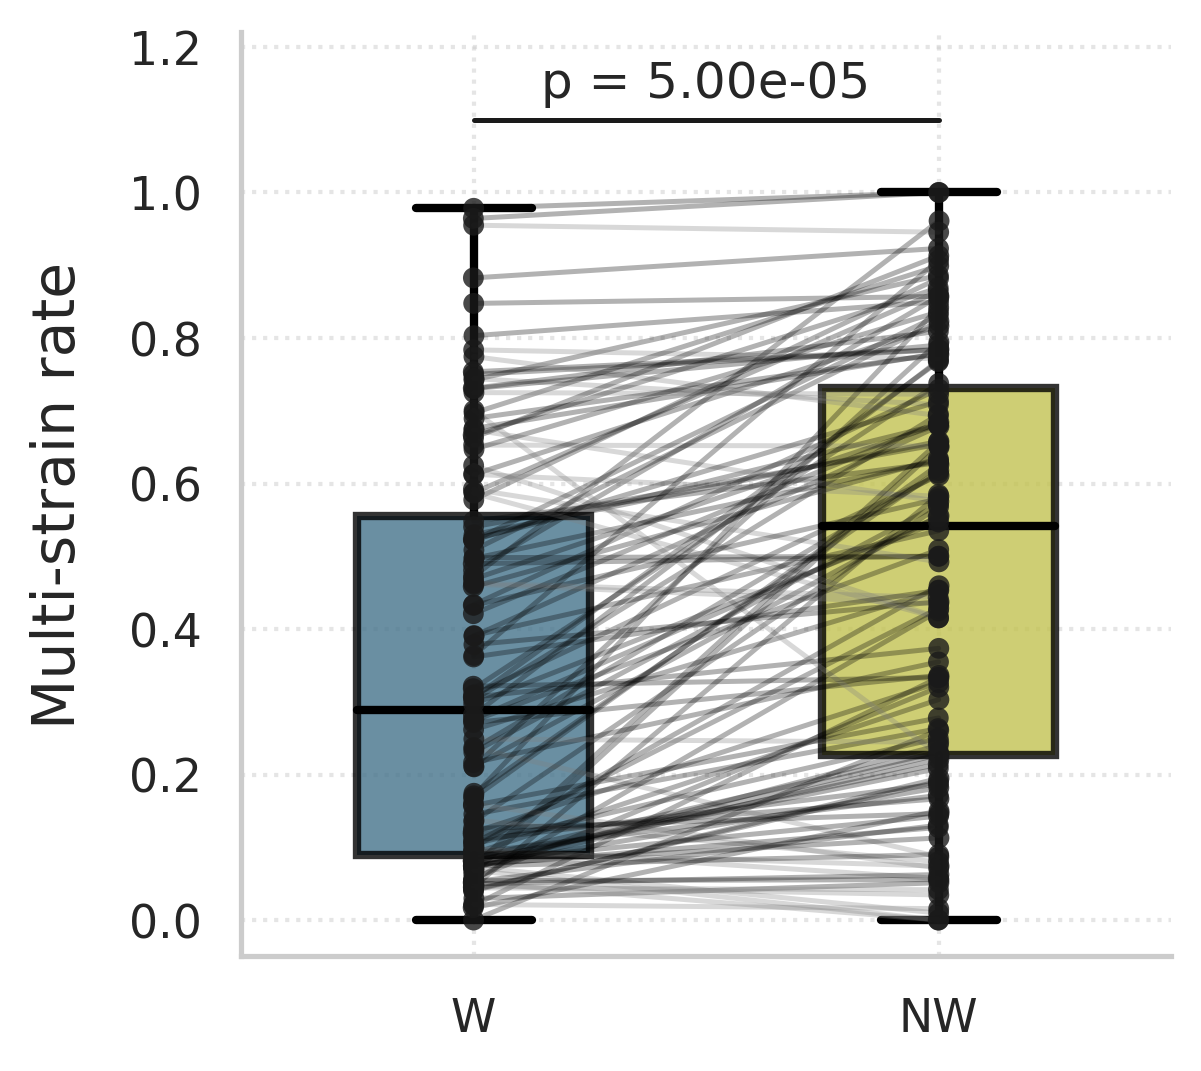

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_multi_strain_boxplot(
    df,
    filepath=None,
    dimensions=(4, 4),
    color_w="#397797",
    color_nw="#d5d53e",
):
    """Plots multi-strain rates by lifestyle with paired SGB trajectory lines."""
    data_df = df.copy()

    # Map categories to match volcano labeling and order
    lifestyle_map = {"no": "W", "yes": "NW"}
    if set(data_df["non_westernized"].unique()).issubset({"no", "yes"}):
        data_df["lifestyle"] = data_df["non_westernized"].map(lifestyle_map)
    else:
        data_df["lifestyle"] = data_df["non_westernized"]

    # Set theme style
    sns.set_theme(style="whitegrid", font="sans-serif")
    palette = {"W": color_w, "NW": color_nw}

    fig, ax = plt.subplots(figsize=dimensions, dpi=300)

    # -------------------------------------------------------------
    # 1. DRAW PAIRED LINES FOR EACH SGB
    # -------------------------------------------------------------
    pivoted = data_df.pivot(
        index="sgb_id", columns="lifestyle", values="multi_strain_rate"
    )

    # Filter to SGBs present in BOTH W and NW groups
    paired_sgbs = pivoted.dropna(subset=["W", "NW"])

    # Draw lines connecting x=0 (W) and x=1 (NW)
    for _, row in paired_sgbs.iterrows():
        line_color = "black" if row["NW"] >= row["W"] else "gray"

        ax.plot(
            [0, 1],
            [row["W"], row["NW"]],
            color=line_color,
            alpha=0.3,
            linewidth=1.2,
            zorder=2,
        )

    # -------------------------------------------------------------
    # 2. BOXPLOT & STRIPPLOT (NO HUE TO PREVENT DODGING/SKINNY BOXES)
    # -------------------------------------------------------------
    # Boxplot: Centered directly on x=0 and x=1 with width=0.5
    sns.boxplot(
        data=data_df,
        x="lifestyle",
        y="multi_strain_rate",
        order=["W", "NW"],
        palette=palette,
        ax=ax,
        width=0.5,  # Solid, normal-sized boxes
        fliersize=0,
        boxprops=dict(alpha=0.8, edgecolor="black", linewidth=2),
        whiskerprops=dict(color="black", linewidth=2),
        capprops=dict(color="black", linewidth=2),
        medianprops=dict(color="black", linewidth=2),
        zorder=1,
    )

    # Stripplot: Centered directly on x=0 and x=1 over the boxplot centers
    sns.stripplot(
        data=data_df,
        x="lifestyle",
        y="multi_strain_rate",
        order=["W", "NW"],
        color="k",
        ax=ax,
        size=5,
        alpha=0.8,
        jitter=0.001,
        zorder=3,
    )

    # -------------------------------------------------------------
    # 3. ANNOTATIONS & AESTHETICS
    # -------------------------------------------------------------
    ax.set_xlabel("", fontsize=14)
    ax.set_ylabel("Multi-strain rate", fontsize=14, labelpad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_ylim(-0.05, 1.22)

    # Significance Bar
    ax.plot([0, 1], [1.1, 1.1], c="k", linewidth=1.2)
    pval = gee_model.pvalues["C(non_westernized)[T.yes]"]

    if pval < 0.0001:
        p_str = f"p = {pval:.2e}"
    else:
        p_str = f"p = {pval:.4f}"

    ax.text(x=0.5, y=1.13, s=p_str, ha="center", fontsize=12,)

    if filepath:
        plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.show()


# Run function
plot_multi_strain_boxplot(
    multi_strain_rates, filepath="../revision/multi_strain_rate.svg"
)

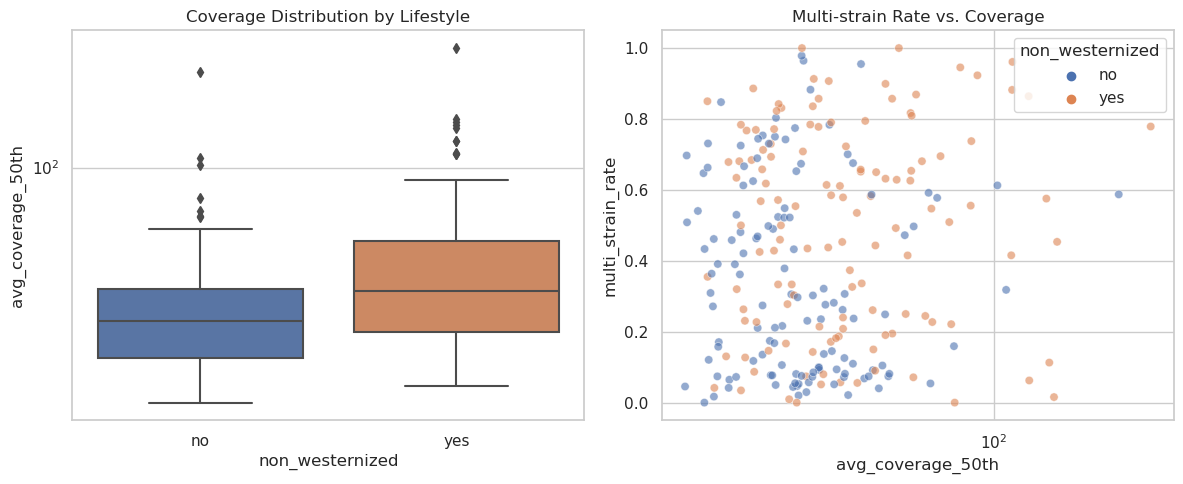

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Does coverage differ by lifestyle?
sns.boxplot(data=multi_strain_rates, x="non_westernized", y="avg_coverage_50th", ax=axes[0])
axes[0].set_title("Coverage Distribution by Lifestyle")
axes[0].set_yscale("log")  # Coverage is often right-skewed

# 2. Does higher coverage drive multi-strain detection?
sns.scatterplot(
    data=multi_strain_rates, 
    x="avg_coverage_50th", 
    y="multi_strain_rate", 
    hue="non_westernized", 
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_xscale("log")
axes[1].set_title("Multi-strain Rate vs. Coverage")

plt.tight_layout()
plt.show()

## 8. Polyallelic positions per SGB
Re-reads the same result files, this time keeping the polyallelic columns and all SGBs, then restricts to `sgbs_selected` from section 2. The first cell used to overwrite `results` from section 3; it now uses `sgb_frames`.

In [ ]:
sgb_frames = []

for study in tqdm(studies):
    study_dir = os.path.join(datadir, study, spa_version)
    if not os.path.exists(study_dir):
        continue

    for exsample in os.listdir(study_dir):
        filedir = os.path.join(
            study_dir, exsample, exsample, f"{exsample}.results.tsv"
        )
        if os.path.exists(filedir):
            try:
                df = pd.read_table(filedir)
                if df.empty:
                    continue

                # Add sample metadata identifiers
                df["study_name"] = study
                df["sample_id"] = exsample
                sgb_frames.append(df)
            except Exception:
                continue

# Combine into a single master SGB-level dataframe
full_sgb_df = pd.concat(sgb_frames, ignore_index=True)

# Merge with your sample metadata (non_westernized, age, gender, read depth, etc.)
df_merged = full_sgb_df.merge(res_df_meta, on="sample_id", how="inner")

# Calculate the continuous polyallelic rate
df_merged["polyallelic_rate"] = (
    df_merged["n_positions_significantly_polyallelic"]
    / df_merged["n_positions_retained"]
)

In [ ]:
df_merged = df_merged.rename(columns={"Unnamed: 0": "SGB"})


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# 1. `sgbs_selected` comes from section 2 (SGBs present in >10% of samples in BOTH lifestyles)

# 2. Filter dataset and use .copy() to avoid SettingWithCopyWarning
df_filtered = df_merged[df_merged.SGB.isin(sgbs_selected)].copy()

# 3. Create log-transformed metrics
df_filtered["log_poly_rate"] = np.log10(df_filtered["polyallelic_rate"] + 1e-5)
df_filtered["log_cov"] = np.log1p(df_filtered["coverage_50th"])

# 4. Clean missing values across ALL model variables before passing to mixedlm
cols_to_use = [
    "log_poly_rate",
    "non_westernized",
    "log_cov",
    "number_reads",
    "age",
    "gender",
    "SGB",
]
df_model = df_filtered[cols_to_use].dropna().copy()

# 5. Fit Linear Mixed Model
model = smf.mixedlm(
    "log_poly_rate ~ C(non_westernized) + log_cov + np.log1p(number_reads) + age + C(gender)",
    data=df_model,
    groups=df_model["SGB"],  # Grouping by SGB controls for taxa baseline
    re_formula="~1",
).fit()

print(model.summary())

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm

sgb_results = []

for sgb in tqdm(sgbs_selected):
    sub_df = df_filtered[df_filtered["SGB"] == sgb].dropna(
        subset=[
            "log_poly_rate",
            "non_westernized",
            "log_cov",
            "number_reads",
            "age",
            "gender",
        ]
    )

    # Require minimum samples in both arms for stability
    counts = sub_df["non_westernized"].value_counts()
    if len(counts) < 2 or counts.min() < 10:
        continue

    # Fit GLM/OLS per SGB
    try:
        m = smf.ols(
            "log_poly_rate ~ C(non_westernized) + log_cov + np.log1p(number_reads) + age + C(gender)",
            data=sub_df,
        ).fit(cov_type="HC3")

        coef = m.params.get("C(non_westernized)[T.yes]", np.nan)
        pval = m.pvalues.get("C(non_westernized)[T.yes]", np.nan)
        stderr = m.bse.get("C(non_westernized)[T.yes]", np.nan)

        sgb_results.append(
            {
                "SGB": sgb,
                "n_obs": len(sub_df),
                "coef_NW": coef,
                "stderr_NW": stderr,
                "pval_NW": pval,
            }
        )
    except Exception:
        continue

res_per_sgb = pd.DataFrame(sgb_results)

# Correct for multiple testing across SGBs (FDR)
_, res_per_sgb["fdr_pval_NW"], _, _ = multipletests(
    res_per_sgb["pval_NW"], method="fdr_bh"
)

# View summary of per-SGB directionality
n_pos = (
    (res_per_sgb["coef_NW"] > 0) & (res_per_sgb["fdr_pval_NW"] < 0.05)
).sum()
n_neg = (
    (res_per_sgb["coef_NW"] < 0) & (res_per_sgb["fdr_pval_NW"] < 0.05)
).sum()

print(f"SGBs with significantly higher polymorphism in NW: {n_pos}")
print(f"SGBs with significantly higher polymorphism in W:  {n_neg}")

In [ ]:
res_per_sgb

In [ ]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_sgb_forest(
    res_per_sgb,
    top_n=30,
    fdr_threshold=0.05,
    dimensions=(8, 12),
    filepath=None,
    color_w="#397797",
    color_nw="#d5d53e",
    color_ns="#888888",
):
    """Generates a Forest Plot for per-SGB regression coefficients (NW vs W polymorphism rate)."""
    df = res_per_sgb.copy()

    # Calculate 95% Confidence Intervals
    df["ci_lower"] = df["coef_NW"] - 1.96 * df["stderr_NW"]
    df["ci_upper"] = df["coef_NW"] + 1.96 * df["stderr_NW"]
    df["is_sig"] = df["fdr_pval_NW"] < fdr_threshold

    # Select top N SGBs ranked by significance
    df_sig = df[df["is_sig"]]
    target_df = df_sig if len(df_sig) >= top_n else df
    plot_df = (
        target_df.sort_values("fdr_pval_NW").head(top_n).sort_values("coef_NW")
    )

    # Figure setup
    fig, ax = plt.subplots(figsize=dimensions, dpi=300)
    sns.set_theme(style="whitegrid", font="sans-serif")

    y_positions = np.arange(len(plot_df))

    # Draw CIs and point estimates
    for i, (_, row) in enumerate(plot_df.iterrows()):
        y_pos = y_positions[i]
        coef = row["coef_NW"]
        ci_low, ci_high = row["ci_lower"], row["ci_upper"]
        is_sig = row["is_sig"]

        # Color logic: positive coef -> higher in NW (color_nw); negative -> higher in W (color_w)
        color = (color_nw if coef > 0 else color_w) if is_sig else color_ns

        # CI line
        ax.plot(
            [ci_low, ci_high],
            [y_pos, y_pos],
            color=color,
            linewidth=1.8,
            alpha=0.9,
        )

        # Point estimate
        ax.scatter(
            coef,
            y_pos,
            color=color,
            marker="o",
            s=65,
            edgecolors="black",
            linewidths=0.6,
            zorder=4,
        )

        # Asterisk annotation
        if is_sig:
            ax.text(
                ci_high + 0.005,
                y_pos,
                "*",
                va="center",
                ha="left",
                fontsize=10,
                fontweight="bold",
                color="black",
            )

    # Aesthetics
    ax.axvline(0, color="black", linestyle="--", linewidth=1.0, alpha=0.7)

    # Alternate row shading
    for i in range(len(plot_df)):
        if i % 2 == 0:
            ax.axhspan(i - 0.4, i + 0.4, color="gray", alpha=0.06, zorder=0)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(plot_df["SGB"], fontsize=11, fontweight="medium")
    ax.set_xlabel(
        "Polymorphism Rate Shift ($\Delta \log_{10}$ NW vs W)",
        fontsize=12,
        labelpad=10,
    )
    ax.set_title(
        f"Top {len(plot_df)} SGBs by Intra-Host Strain Diversity Shift",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle=":", alpha=0.6)
    ax.grid(axis="y", visible=False)

    # Legend
    legend_elements = [
        mpatches.Patch(
            facecolor=color_nw,
            edgecolor="black",
            linewidth=0.8,
            label="Higher in Non-Westernized (NW)",
        ),
        mpatches.Patch(
            facecolor=color_w,
            edgecolor="black",
            linewidth=0.8,
            label="Higher in Westernized (W)",
        ),
        mpatches.Patch(
            facecolor=color_ns,
            edgecolor="black",
            linewidth=0.8,
            label="Non-significant (FDR >= 0.05)",
        ),
    ]
    ax.legend(
        handles=legend_elements,
        loc="lower right",
        frameon=True,
        facecolor="white",
        framealpha=0.9,
        fontsize=10,
    )

    plt.tight_layout()
    if filepath:
        plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.show()


# Example Call:
plot_sgb_forest(res_per_sgb, top_n=50, filepath="sgb_forest_plot.png")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_sgb_volcano(
    res_per_sgb,
    fdr_threshold=0.05,
    label_top_n=10,
    dimensions=(6,4),
    filepath=None,
    color_w="#397797",
    color_nw="#d5d53e",
    color_ns="#888888",
):
    """Generates a Volcano Plot for per-SGB regression results."""
    df = res_per_sgb.copy()

    # Calculate -log10(FDR p-value)
    df["log_pval"] = -np.log10(
        np.where(df["fdr_pval_NW"] == 0, 1e-300, df["fdr_pval_NW"])
    )
    df["is_sig"] = df["fdr_pval_NW"] < fdr_threshold

    # Plot setup
    fig, ax = plt.subplots(figsize=dimensions, dpi=300)
    sns.set_theme(style="whitegrid", font="sans-serif")

    # Group colors
    colors = []
    for _, row in df.iterrows():
        if not row["is_sig"]:
            colors.append(color_ns)
        elif row["coef_NW"] > 0:
            colors.append(color_nw)
        else:
            colors.append(color_w)

    # Scatter plot
    scatter = ax.scatter(
        df["coef_NW"],
        df["log_pval"],
        c=colors,
        s=30,
        alpha=0.85,
        edgecolors="black",
        linewidths=0.6,
        zorder=3,
    )

    # Threshold lines
    ax.axvline(0, color="black", linestyle="--", linewidth=1.0, alpha=0.7)
    y_thresh = -np.log10(fdr_threshold)
    ax.axhline(
        y_thresh,
        color="red",
        linestyle=":",
        linewidth=1.2,
        alpha=0.8,
        label=f"FDR = {fdr_threshold}",
    )

    # Label top SGBs
    if label_top_n > 0:
        top_sgbs = df.sort_values("fdr_pval_NW").head(label_top_n)
        for _, row in top_sgbs.iterrows():
            ax.annotate(
                row["SGB"][3:],
                (row["coef_NW"], row["log_pval"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=12,
                # fontweight="bold",
                alpha=0.9,
            )

    # Aesthetics
    ax.set_xlabel(
        "log10(coefficient)",
        fontsize=14,
        labelpad=10,
    )
    ax.set_ylabel(
        "log10(q-value)",
        fontsize=14,
        labelpad=10,
    )
    # ax.set_title(
    #     "Intra-Host Strain Polymorphism Across Shared SGBs",
    #     fontsize=13,
    #     fontweight="bold",
    #     pad=15,
    # )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linestyle=":", alpha=0.5)

    # Annotate summary counts in plot corners
    n_nw = ((df["coef_NW"] > 0) & df["is_sig"]).sum()
    n_w = ((df["coef_NW"] < 0) & df["is_sig"]).sum()

    plt.xlim(-1.1,1.1)


    plt.tight_layout()
    if filepath:
        plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.show()


# Example Call:
plot_sgb_volcano(res_per_sgb, label_top_n=10, filepath="sgb_volcano_plot.png")